In [1]:
%load_ext autoreload
import numpy as np
from utils.data_loader import *
from models import *
import torch.optim as optim
import torch
import torch.nn as nn
import l4casadi
import plotly.graph_objects as go


In [3]:
%autoreload 2
parent = ''
filter = pd.concat([pd.read_csv(parent+'data/nodes/c1.csv'),pd.read_csv(parent+'data/nodes/c2.csv'),pd.read_csv(parent+'data/nodes/sus.csv'),pd.read_csv(parent+'data/nodes/outer_wall.csv')])
data_dict,mu_dict,nodes,_ = load_raw_data(parent+'data/raw_data/', filter3D=filter, mu_keys=['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)', 'Pyro 3D (°C)'])      

In [26]:
pyro_pw1 = mu_dict['PW1']['mu'][:,-1]
temps_pw1 = data_dict['PW1']['temps']
print(temps_pw1.shape)


for temp in pyro_pw1:
    print(np.where(temps_pw1 == temp)[0])
pyro_picker = np.zeros((1,temps_pw1.shape[0]))
pyro_picker[:,4175] = 1
np.savetxt('data/core_regions/pyro_picker.csv', pyro_picker)

(4184, 61)
[  30  225  229  241  261  414  420  609  786  994  997 1069 1303 1717
 1721 1728 1759 1864 1958 2294 2298 2348 2360 2487 2528 2696 2755 2777
 3018 3083 3206 3213 3255 3259 3392 3410 3541 3580 3587 3589 3797 3801
 3851 3852 3857 3865 3875 3879 3919 3927 4040 4066 4169 4172 4175]
[]
[4175]
[]
[]
[]
[]
[]
[4175]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[4175]
[]
[4175]
[]
[]
[4175]
[4175]
[4175]
[]
[]
[4175]
[]
[4175]
[]
[]
[]
[]
[]
[4175]
[]
[4175]
[]
[4175]
[]
[]
[]
[]
[]
[]
[]
[]
[4175]
[]
[]
[]
[4175]
[]
[]


In [137]:
df = pd.DataFrame(nodes, columns=['X','Y','Z'])
c2 = df[['X', 'Y', 'Z']]
c2 = c2[c2['Z'] >= 0.1]
c2 = c2[c2['Z'] <= 1.1]
c2 = c2[(c2['X'] - 0.44)**2 + c2['Y']**2 <= (0.2)**2]
c2.to_csv(parent+'data\\nodes\\c2.csv')

In [138]:
c1 = pd.read_csv(parent+'data\\nodes\\c1.csv')[['X', 'Y', 'Z']].to_numpy()
c2 = pd.read_csv(parent+'data\\nodes\\c2.csv')[['X', 'Y', 'Z']].to_numpy()
sus = pd.read_csv(parent+'data\\nodes\\sus.csv')[['X', 'Y', 'Z']].to_numpy()
outer_wall = pd.read_csv(parent+'data\\nodes\\outer_wall.csv')[['X', 'Y', 'Z']].to_numpy()

In [139]:
c1_picker = np.zeros((c1.shape[0], nodes.shape[0]))
for i, row in enumerate(c1):
    for j, row_ in enumerate(nodes):
        if (row == row_).all():
            c1_picker[i,j] = 1
np.savetxt('data/core_regions/c1_picker.txt', c1_picker)

In [140]:
c2_picker = np.zeros((c2.shape[0], nodes.shape[0]))
for i, row in enumerate(c2):
    for j, row_ in enumerate(nodes):
        if (row == row_).all():
            c2_picker[i,j] = 1
np.savetxt('data/core_regions/c2_picker.txt', c2_picker)

In [141]:
sus_picker = np.zeros((sus.shape[0], nodes.shape[0]))
for i, row in enumerate(sus):
    for j, row_ in enumerate(nodes):
        if (row == row_).all():
            sus_picker[i,j] = 1
np.savetxt('data/core_regions/sus_picker.txt', sus_picker)

In [142]:
outer_wall_picker = np.zeros((outer_wall.shape[0], nodes.shape[0]))
for i, row in enumerate(outer_wall):
    for j, row_ in enumerate(nodes):
        if (row == row_).all():
            outer_wall_picker[i,j] = 1
np.savetxt('data/core_regions/outer_wall_picker.txt', outer_wall_picker)

In [143]:
assert c1_picker.shape[0] == c1.shape[0]
assert c2_picker.shape[0] == c2.shape[0]
assert sus_picker.shape[0] == sus.shape[0]
assert outer_wall_picker.shape[0] == outer_wall.shape[0]
assert (c1_picker @ nodes == c1).all()
assert (sus_picker @ nodes == sus).all()
assert (c2_picker @ nodes == c2).all()
assert (outer_wall_picker @ nodes == outer_wall).all()

Fitting the cooling power equation

In [ ]:
temps = []
mu = []
for run in data_dict.keys():
    temps.append(data_dict[run]['temps'])
    mu.append(mu_dict[run]['mu'])
temps = np.hstack(temps)
mu = np.hstack(mu)

(4184, 2135)


In [160]:
from scipy.optimize import curve_fit

wall_temps = torch.tensor((outer_wall_picker @ temps)).mean(dim=0)
print(wall_temps.shape)
Cv = 10 #kW/K/m3
Tw = 20 #C
a = 1.09 #m3/s
pwr_cool = mu[:,1]
x_ = np.arange(pwr_cool.shape[0])
pwr_cool_th = lambda x,a: -a*Cv*(Tw - wall_temps[x])

popt, pcov = curve_fit(pwr_cool_th, x_, pwr_cool, p0=[1.0])
a_best = popt[0]
print("Best fit a:", a_best)


torch.Size([2135])
Best fit a: 1.0771871392122856


In [162]:
np.savetxt('data/cooling_coef.txt', np.array([[a_best]]))

In [44]:
c1 = pd.read_csv(parent+'data\\nodes\\c1.csv')[['X', 'Y', 'Z']].to_numpy()
c2 = pd.read_csv(parent+'data\\nodes\\c2.csv')[['X', 'Y', 'Z']].to_numpy()
sus = pd.read_csv(parent+'data\\nodes\\sus.csv')[['X', 'Y', 'Z']].to_numpy()
outer_wall = pd.read_csv(parent+'data\\nodes\\outer_wall.csv')[['X', 'Y', 'Z']].to_numpy()
def plot_point_cloud(nodes_list, color_list=None, name_list = None, base_list = None, cmap='Viridis', title='3D Point Cloud', filename='point_cloud.html', show_plot=False):
    """
    nodes: np array (N, 3) — columns: [R, angle, Z]
    color: None, a single color string, or an array of length N for colormap
    """
    if base_list is None:
        base_list = ['cyl' for _ in nodes_list]
    X = []
    Y = []
    Z = []
    markers = []
    fig = go.Figure()
    for i, nodes in enumerate(nodes_list):
            
        R = nodes[:, 0]
        theta = nodes[:, 1]  # radians, use np.deg2rad(nodes[:,1]) if degrees
        Z.append(nodes[:, 2])
        if base_list[i] == 'cyl':
            X.append(R * np.cos(theta))
            Y.append(R * np.sin(theta))
        elif base_list[i] == 'xyz':
            X.append(R)
            Y.append(theta)
        else:
            raise
        marker = dict(size=3, colorscale=cmap, showscale=True)

        if color_list is None:
            marker['color'] = 'steelblue'
            marker['showscale'] = False
        elif isinstance(color_list, list):
            marker['color'] = color_list[i]
            marker['showscale'] = False
        else:
            marker['color'] = color_list[i]
        markers.append(marker)
        if not name_list is None:
            name = name_list[i]
        else:
            name = f'Series {i}'


        fig.add_trace(go.Scatter3d(
            x=X[i], y=Y[i], z=Z[i],
            mode='markers',
            marker=marker,
            name=name                ))

    fig.update_layout(
    title=title,
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'  # preserves true proportions
    )
)


    if show_plot:
        fig.show()  # also shows inline in notebook
    else:
        fig.write_html(filename)
        print(f"Saved to {filename}")

# no color
#plot_point_cloud([nodes.to_numpy(), c1, c2], ['red', 'blue', 'green'], ['Void', 'Crucible 1', 'Crucible 2'], base_list=['cyl', 'cyl', 'xyz'], filename=)
plot_point_cloud([c1, c2, sus, outer_wall], ['tomato', 'steelblue', 'orange', 'orange', 'pink', 'tomato'], ['Crucible 1', 'Crucible 2', 'Susceptor', 'C2S', 'Sus', 'Outer wall'], base_list=['xyz', 'xyz', 'xyz', 'xyz', 'xyz', 'xyz'], filename='3Dtemps.html', show_plot=False)

Saved to 3Dtemps.html


In [ ]:
df = pd.read_csv('data/raw_data/PW1_Resultsabridged.csv')

Index(['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)',
       'Pyro 3D (°C)'],
      dtype='str')


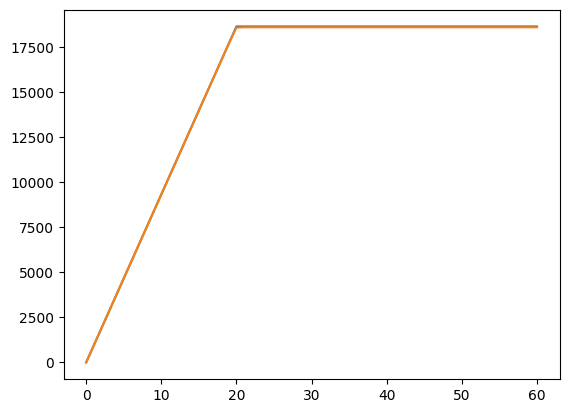

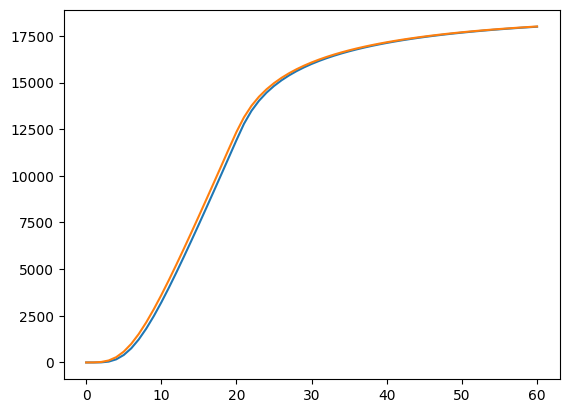

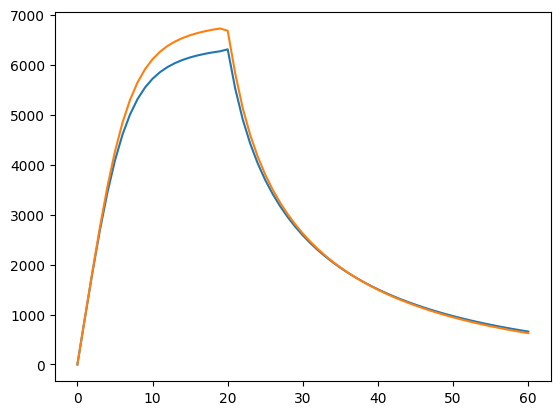

In [228]:
from scipy.integrate import cumulative_trapezoid
print(mu_dict['PW1']['columns'])
H_int = utilities.integrate_series(mu_dict['PW1']['mu'][:,0].reshape(-1,1))
C_int = utilities.integrate_series(mu_dict['PW1']['mu'][:,1].reshape(-1,1)) + mu_dict['PW1']['mu'][0,1]*0.5

plt.plot(H_int)
plt.plot(1000*df['Input Energy 3D (MWh)'])
plt.show()
plt.plot(1000*df['Cooling Energy 3D (MWh)'])
plt.plot(C_int)
plt.show()
plt.plot(H_int - C_int)
plt.plot(mu_dict['PW1']['mu'][:,2].reshape(-1,1))


In [90]:
num = {int(k.split('W')[-1]):k for k in mu_dict.keys()}

import plotly.graph_objects as go
from plotly.subplots import make_subplots

rows, cols = 4, 5
start = 16

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f'{i*cols + j + start}' for i in range(rows) for j in range(cols)]#*(rows*cols)#[f"Plot {i+1}" for i in range(rows * cols)]
)

x = np.arange(0, 30, 0.5)

for i in range(rows):
    for j in range(cols):
        key_idx = (i*cols + j) + start
        key = num[key_idx]
        y = mu_dict[key]['mu'][:,0]  # dummy data, swap for your own
        fig.add_trace(
            go.Scatter(x=x, y=y, mode="lines", showlegend=False, name=key_idx),
            row=i + 1, col=j + 1
        )
                # set the title for this subplot as you go
        fig.update_xaxes(title_text="Time (h)",row=i + 1, col=j + 1)
        fig.update_yaxes(title_text="Power (kW)", range=[0,2000],row=i + 1, col=j + 1)
        fig.update
        # print(fig.layout.annotations)
        # fig.layout.subplot_titles[i*rows + j].text = title_text

fig.update_layout(height=250 * rows, width=350 * cols, title_text="Heating power profiles, batch 2")
fig.show()

In [152]:
xticks = [[k] + ['']*4 for k in np.round(np.linspace(0,0.75,11),3)]
xticks = np.hstack(xticks)[:50]
yticks = [['']*4 + [k] for k in np.round(np.linspace(0.2,1.2,11),3)]
yticks.reverse()
yticks = np.hstack(yticks)[4:]
yticks


array(['1.2', '', '', '', '', '1.1', '', '', '', '', '1.0', '', '', '',
       '', '0.9', '', '', '', '', '0.8', '', '', '', '', '0.7', '', '',
       '', '', '0.6', '', '', '', '', '0.5', '', '', '', '', '0.4', '',
       '', '', '', '0.3', '', '', '', '', '0.2'], dtype='<U32')

(50, 50)


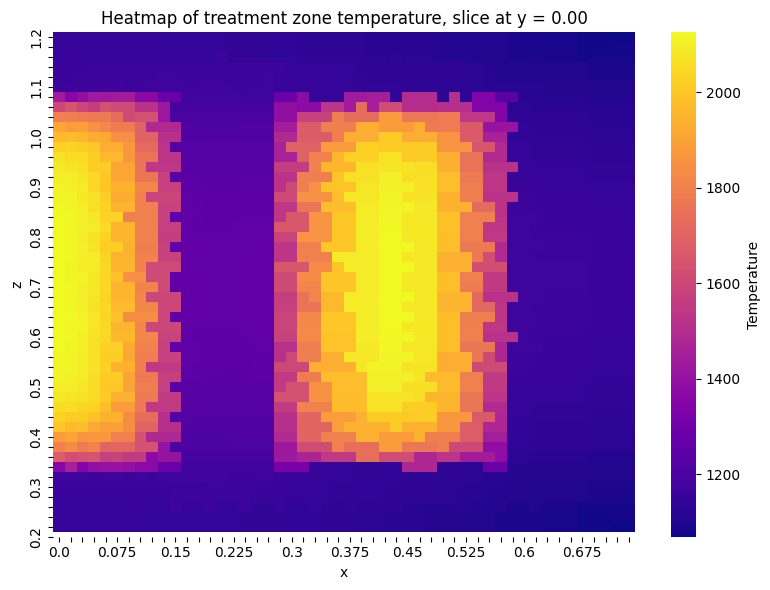

In [153]:
import seaborn as sns
from scipy.interpolate import griddata


def plot_temp_slice(nodes, temps, plane='z', slice_val=None, tol=0.5, grid_res=50, title=''):
    """
    Parameters:
        nodes     : (N, 3) array of node positions
        temps     : (N,)   array of temperatures
        plane     : 'x', 'y', or 'z' — normal axis of the slice
        slice_val : value along the plane axis to slice at (defaults to midpoint)
        tol       : tolerance for selecting nodes near the slice
        grid_res  : resolution of the interpolation grid
    """
    axis = {'x': 0, 'y': 1, 'z': 2}[plane]
    ax1, ax2 = [i for i in range(3) if i != axis]
    labels = ['x', 'y', 'z']

    if slice_val is None:
        slice_val = np.median(nodes[:, axis])

    # Select nodes near the slice plane
    mask = np.abs(nodes[:, axis] - slice_val) < tol
    if mask.sum() < 3:
        raise ValueError(f"Only {mask.sum()} nodes found near {plane}={slice_val}, increase tol")

    pts  = nodes[mask][:, [ax1, ax2]]
    vals = temps[mask]

    # Interpolate onto a regular grid
    u = np.linspace(pts[:, 0].min(), pts[:, 0].max(), grid_res)
    v = np.linspace(pts[:, 1].min(), pts[:, 1].max(), grid_res)
    uu, vv = np.meshgrid(u, v)
    grid_temps = griddata(pts, vals, (uu, vv), method='nearest')

    # Plot
    print(grid_temps.shape)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        grid_temps,
        ax=ax,
        cmap='plasma',
        cbar_kws={'label': 'Temperature'},
        xticklabels=xticks,#np.round(u[::grid_res//5], 2),
        yticklabels=yticks,#]np.round(v[::grid_res//5], 2)
    )
    ax.set_xlabel(labels[ax1])
    ax.set_ylabel(labels[ax2])
    ax.set_title(title + f', slice at {plane} = {slice_val:.2f}')
    plt.tight_layout()
    plt.show()

plot_temp_slice(nodes, temps=data_dict['PW1']['temps'][:,30], plane='y', slice_val=0.0, tol=0.01, title='Heatmap of treatment zone temperature')


In [101]:
data_dict['PW1']['temps'][:,30].shape, nodes.shape

((4038,), (4038, 3))